In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from waymo_agent import *

In [3]:
# from kret_studies import *
# from kret_studies.notebook import *
# from kret_studies.complex import *

# logger = get_notebook_logger()

In [4]:
from waymo_agent.osmnx import *
from waymo_agent.osmnx.inspect import *
from waymo_agent.osmnx.osmnx_constants import *
from waymo_agent.osmnx.sparsify import *
from waymo_agent.osmnx.utils import _max_speed_int
from waymo_agent.osmnx.post_process_enrichment import *

#### Load Sparse Graph

In [5]:
config = EnvConfig()
config.map_name

'manhattan-sparse-774-nodes-enriched.graphml'

In [6]:
G_raw = ox.load_graphml(filepath=MAP_DIR / config.map_name)
# post_load(G_raw)

In [7]:
inspect_graph(G_raw)

Graph has 774 nodes and 1613 edges.
Sample node -sample_node_id=42425484- attributes: {'y': 40.814759, 'x': -73.9343888, 'street_count': 3, 'lambda': '0.0257', 'x_centered': '3734.904', 'y_centered': '6703.5703', 'x_norm': '0.5215', 'y_norm': '0.9361'}

Sample edge attributes: {'osmid': 194923792, 'highway': 'secondary', 'lanes': "('2', '3')", 'maxspeed': '25.0', 'name': 'West 15th Street', 'oneway': True, 'reversed': False, 'length': 79.82897059426534, 'geometry': <LINESTRING (-74.008 40.743, -74.008 40.743, -74.008 40.743, -74.008 40.743,...>, 'travel_time_minutes': '0.1916'}


In [8]:
env = RideShareEnv()
G = env.graph

/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


In [9]:
obs, info = env.reset()

In [10]:
from waymo_agent.osmnx.shortest_path import calculate_longest_path


maxlen, path = calculate_longest_path(G, weight="length")
maxlen, len(path)

(18244.60388871296, 59)

In [11]:
node_id = env.nearest_node_id(0, 0)

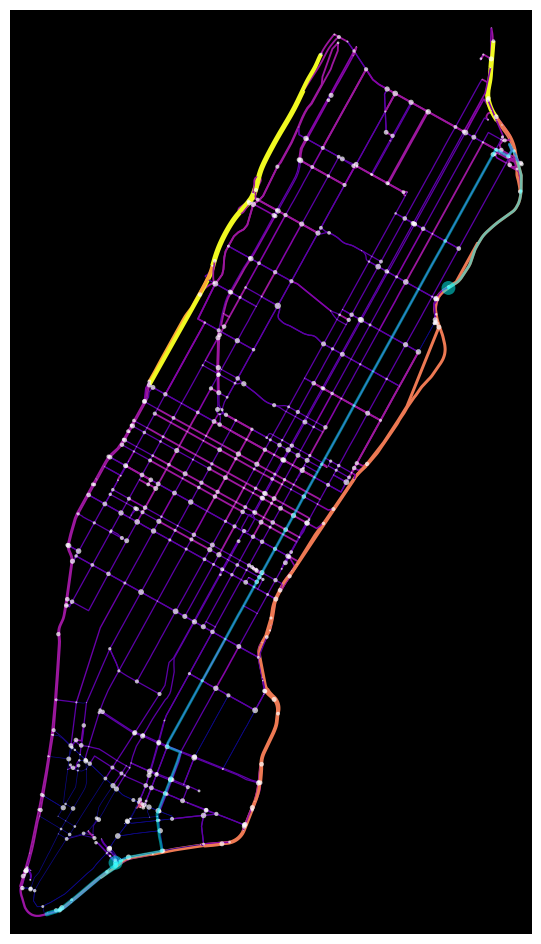

In [12]:
edge_colors, edge_widths = get_edge_color_by_speed(G)
node_colors, node_sizes = get_node_colors_and_sizes(G)
fig, ax = ox.plot_graph(
    G,
    edge_color=edge_colors,
    edge_linewidth=edge_widths,
    node_size=node_sizes,
    node_color=node_colors,
    figsize=(12, 12),
    show=False,
    bgcolor="black",
    node_alpha=0.7,
)
ox.plot_graph_route(G, path, route_color="cyan", route_linewidth=2.0, ax=ax, orig_dest_node_size=100)
# nx.draw_networkx_nodes(G, pos=env.pos_norm, nodelist=[node_id], node_color="red", node_size=200, ax=ax)
x_norm, y_norm = env.pos_norm[node_id]
ax.scatter(x_norm, y_norm, c="red", s=200, zorder=5)
x, y = env.pos_raw[node_id]
ax.scatter(x, y, c="red", s=20000)

In [13]:
x_norm, y_norm, x, y

(0.0011, 0.0098, -73.9794895, 40.7554134)

In [14]:
node_sizes[0:10]

[8.81, 6.06, 7.79, 11.71, 4.51, 0.5, 7.36, 0.5, 0.5, 1.95]

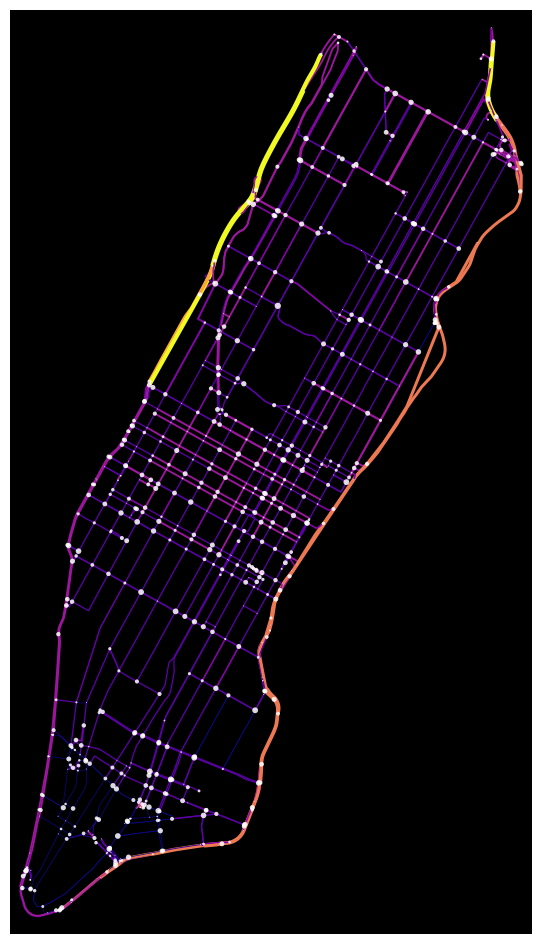

In [29]:
fig, ax = env.render(figsize=(12, 12))
# x_norm, y_norm = env.pos_norm[node_id]
# ax.scatter(x_norm, y_norm, c="red", s=200, zorder=5)
x, y = env.pos_raw[node_id]
_ = ax.scatter(x, y, c="red", s=200)